# SKAX 멤버십 데이터 탐색적 데이터 분석 (EDA)

> **목표**: 스트리밍 서비스 멤버십 데이터를 단계별로 분석하여 데이터 구조, 분포, 패턴을 파악한다.

---

### 데이터 컬럼 설명
| 컬럼명 | 설명 |
|---|---|
| user_no | 사용자 고유 ID (해시값) |
| product_cd | 가입한 상품 코드 |
| amount | 결제 금액 |
| billing_method | 결제 수단 코드 |
| concurrent_streams | 동시 스트리밍 허용 수 |
| promotion_yn | 프로모션 적용 여부 (O = 적용) |
| is_churn_prevented | 이탈 방지 처리 여부 (O = 방지됨) |
| repurchase | 재구매 여부 (O = 재구매) |
| payment_device | 결제 기기 (pc / android / ios) |
| is_user_verified | 사용자 인증 여부 (Y / N) |
| gender | 성별 (F = 여성, M = 남성, N = 미제공) |
| age | 나이 |
| reg_date | 서비스 등록일 |
| reg_hour | 등록 시각 (시 단위) |
| end_date | 서비스 종료일 |

## 1단계. 라이브러리 임포트

In [1]:
# 데이터 분석 및 시각화에 필요한 라이브러리를 불러옵니다
import pandas as pd           # 데이터프레임 처리
import numpy as np            # 수치 연산
import matplotlib.pyplot as plt   # 그래프 기본
import seaborn as sns         # 통계 시각화

# 한글 폰트 설정 (그래프에 한글이 깨지지 않도록)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 경고 메시지 숨기기
import warnings
warnings.filterwarnings('ignore')

print("라이브러리 임포트 완료!")

라이브러리 임포트 완료!


## 2단계. 데이터 불러오기 및 기본 정보 확인

In [2]:
# CSV 파일을 읽어옵니다 (encoding='utf-8-sig'는 BOM 문자를 처리해줍니다)
df = pd.read_csv('Membership.csv', encoding='utf-8-sig')

# 데이터 크기 확인: (행 수, 열 수)
print(f"데이터 크기: {df.shape[0]:,}행 × {df.shape[1]}열")
print()

# 처음 5행 미리보기
print("=== 데이터 미리보기 (상위 행) ===")
df.head(3)

데이터 크기: 18,183행 × 15열

=== 데이터 미리보기 (상위 행) ===


,user_no,product_cd,amount,billing_method,concurrent_streams,promotion_yn,is_churn_prevented,repurchase,payment_device,is_user_verified,gender,age,reg_date,reg_hour,end_date
0,7a6960912bebe03c6e4c770eb1aa91329c3497f18f90ca...,pk_1489,100.0,134,4.0,O,NaN,NaN,pc,Y,F,20.0,2021-03-14,20,2021-04-14
1,4ec765db76545c1d6dda9f421590bf9d02f584009f8d92...,pk_1487,100.0,190,1.0,O,O,NaN,pc,Y,F,25.0,2021-03-09,14,2021-04-09
2,4f86d917c53cb6bd8949f76dba7260311e8c1748748a02...,pk_1487,100.0,132,1.0,O,NaN,NaN,android,NaN,F,55.0,2021-03-09,22,2021-04-09


In [3]:
# 각 컬럼의 데이터 타입과 null이 아닌 값의 수를 확인합니다
print("=== 컬럼별 데이터 타입 및 기본 정보 ===")
df.info()

=== 컬럼별 데이터 타입 및 기본 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18183 entries, 0 to 18182
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_no             18183 non-null  object 
 1   product_cd          18183 non-null  object 
 2   amount              18183 non-null  float64
 3   billing_method      18183 non-null  int64  
 4   concurrent_streams  18113 non-null  float64
 5   promotion_yn        9203 non-null   object 
 6   is_churn_prevented  3257 non-null   object 
 7   repurchase          11931 non-null  object 
 8   payment_device      18183 non-null  object 
 9   is_user_verified    17583 non-null  object 
 10  gender              18019 non-null  object 
 11  age                 18019 non-null  float64
 12  reg_date            18183 non-null  object 
 13  reg_hour            18183 non-null  int64  
 14  end_date            18183 non-null  object 
dtypes: float64(3), int64(2), o

In [4]:
# 수치형 컬럼(숫자 데이터)의 기초 통계량을 확인합니다
# count: 값 개수, mean: 평균, std: 표준편차, min/max: 최솟값/최댓값, 25%/50%/75%: 사분위수
print("=== 수치형 변수 기초 통계량 ===")
df.describe()

=== 수치형 변수 기초 통계량 ===


,amount,billing_method,concurrent_streams,age,reg_hour
count,18183.000000,18183.000000,18113.000000,18019.000000,18183.000000
mean,3032.774402,146.783809,1.699056,33.923359,13.597536
std,4456.244413,18.826456,1.089840,12.606441,7.312541
min,7.690000,121.000000,1.000000,0.000000,0.000000
25%,100.000000,134.000000,1.000000,25.000000,9.000000
50%,100.000000,140.000000,1.000000,35.000000,15.000000
75%,7900.000000,151.000000,2.000000,40.000000,20.000000
max,16400.000000,190.000000,4.000000,950.000000,23.000000


## 3단계. 결측치(빈 값) 분석

> 결측치란 데이터가 없는(비어있는) 값입니다. 분석 전에 반드시 확인해야 합니다.

=== 결측치 현황 ===
                    결측치 수  결측치 비율(%)
is_churn_prevented  14926      82.09
promotion_yn         8980      49.39
repurchase           6252      34.38
is_user_verified      600       3.30
gender                164       0.90
age                   164       0.90
concurrent_streams     70       0.38



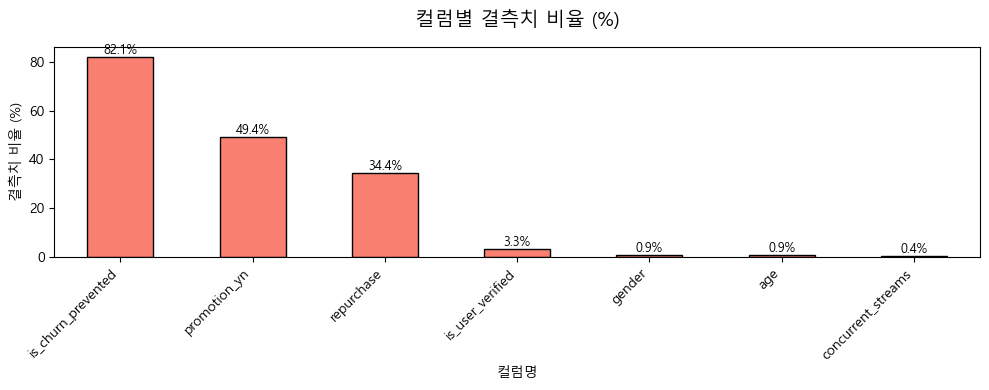

In [5]:
# 컬럼별 결측치 수와 비율을 계산합니다
missing_count = df.isnull().sum()               # 결측치 개수
missing_ratio = (df.isnull().sum() / len(df) * 100).round(2)  # 결측치 비율(%)

# 결측치가 있는 컬럼만 표로 정리
missing_df = pd.DataFrame({
    '결측치 수': missing_count,
    '결측치 비율(%)': missing_ratio
}).query('`결측치 수` > 0').sort_values('결측치 비율(%)', ascending=False)

print("=== 결측치 현황 ===")
print(missing_df)
print()

# 시각화: 결측치 비율을 막대 그래프로 표시
if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['결측치 비율(%)'].plot(kind='bar', ax=ax, color='salmon', edgecolor='black')
    ax.set_title('컬럼별 결측치 비율 (%)', fontsize=14, pad=15)
    ax.set_xlabel('컬럼명')
    ax.set_ylabel('결측치 비율 (%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    # 각 막대 위에 수치 표시
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("결측치가 없습니다!")

## 4단계. 범주형 변수 분포 분석

> 범주형 변수란 성별, 기기 종류처럼 몇 가지 분류로 나뉘는 데이터입니다.

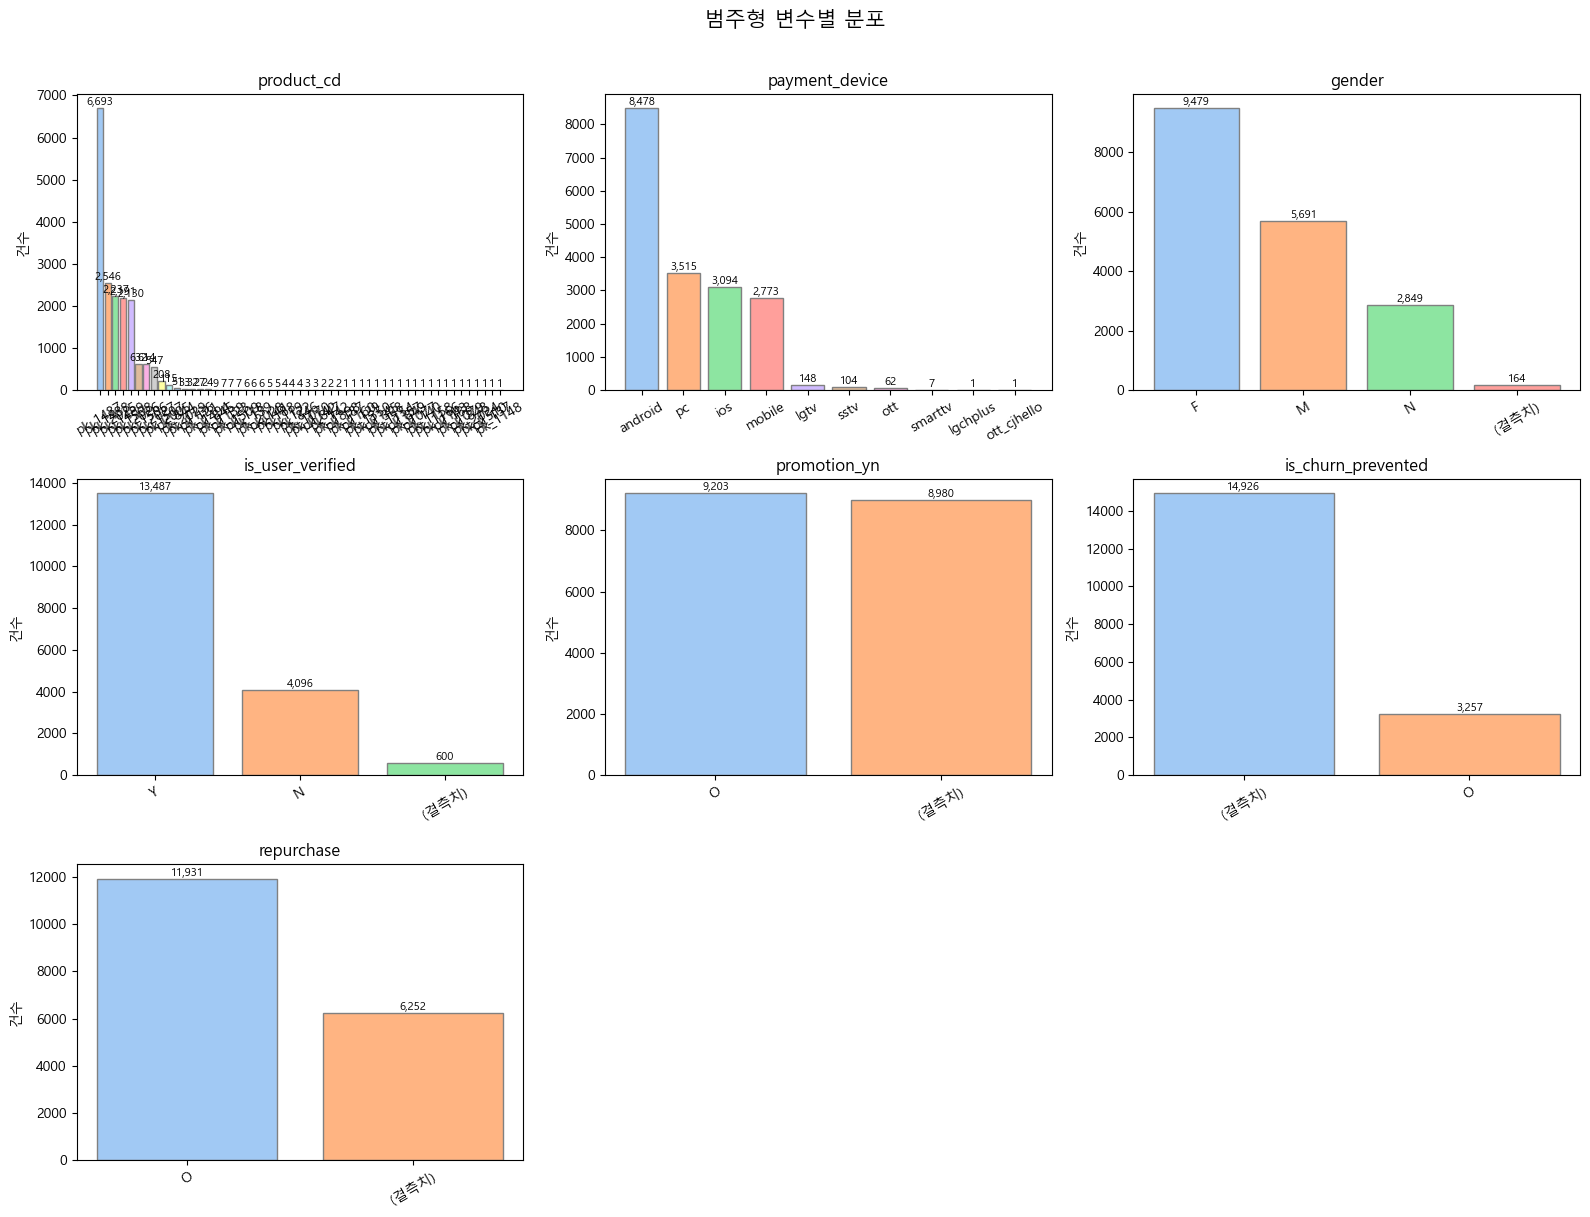

In [6]:
# 분석할 범주형 컬럼 목록
cat_cols = ['product_cd', 'payment_device', 'gender', 'is_user_verified',
            'promotion_yn', 'is_churn_prevented', 'repurchase']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()  # 2차원 배열을 1차원으로 펴서 반복문에서 쓰기 쉽게 함

for i, col in enumerate(cat_cols):
    # 각 값의 빈도수를 세고 내림차순 정렬
    val_counts = df[col].fillna('(결측치)').value_counts()
    
    ax = axes[i]
    bars = ax.bar(val_counts.index.astype(str), val_counts.values,
                  color=sns.color_palette('pastel'), edgecolor='gray')
    ax.set_title(f'{col}', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('건수')
    ax.tick_params(axis='x', rotation=30)
    
    # 막대 위에 건수 표시
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

# 남은 빈 subplot 숨기기
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('범주형 변수별 분포', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 5단계. 수치형 변수 분포 분석

> 수치형 변수란 금액, 나이처럼 숫자로 표현되는 데이터입니다.

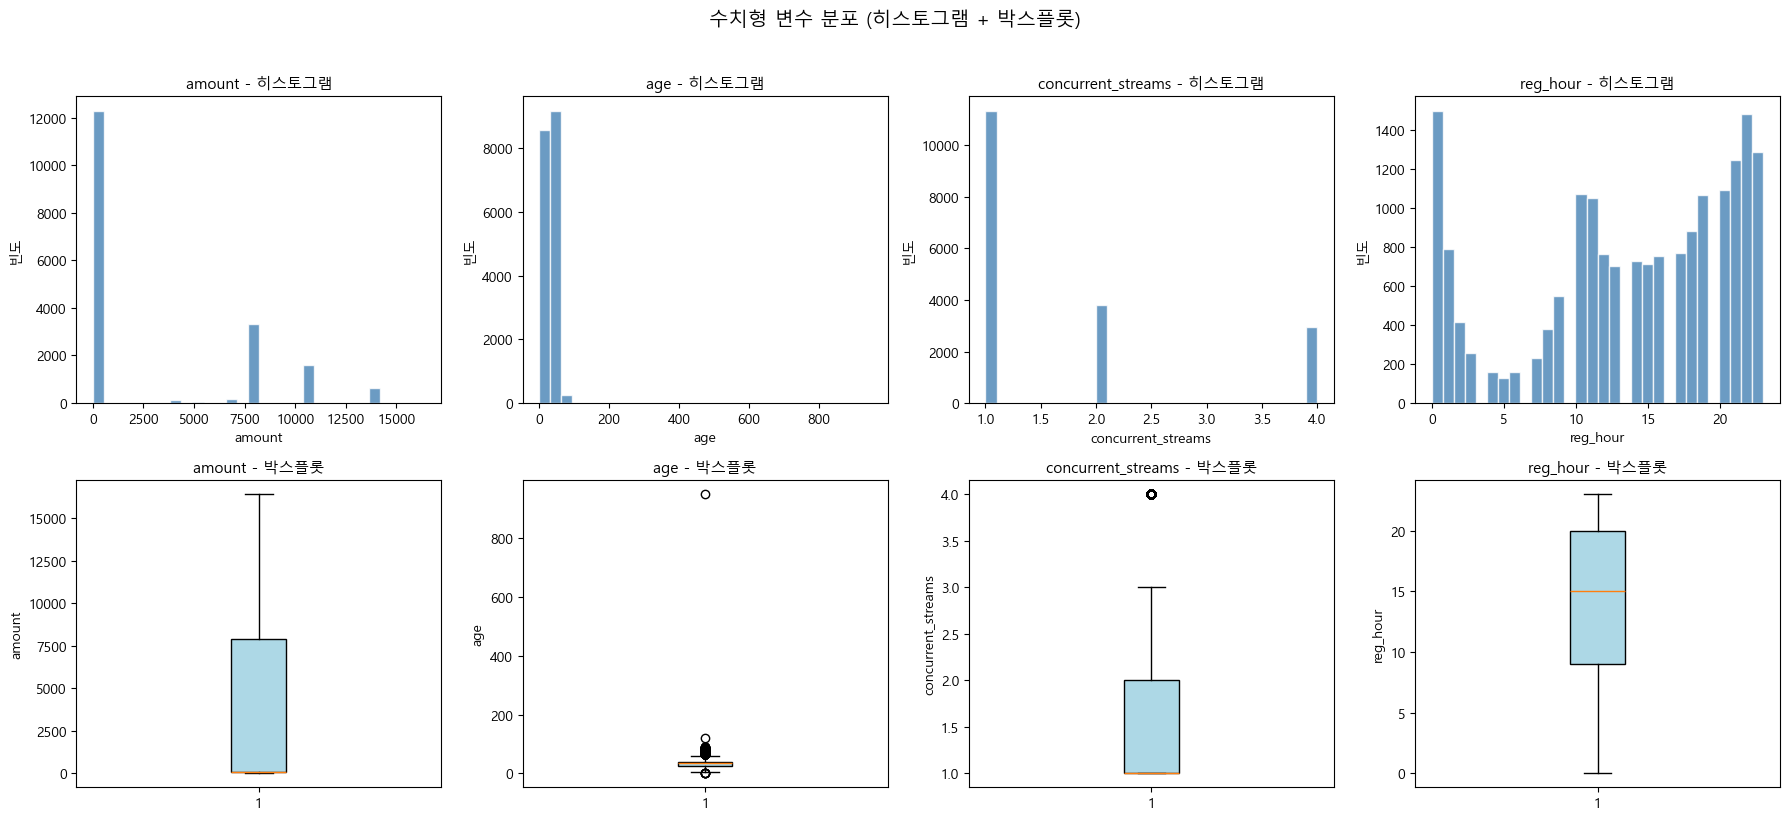


=== 수치형 변수 통계 요약 ===


,amount,age,concurrent_streams,reg_hour
count,18183.00,18019.00,18113.00,18183.00
mean,3032.77,33.92,1.70,13.60
std,4456.24,12.61,1.09,7.31
min,7.69,0.00,1.00,0.00
25%,100.00,25.00,1.00,9.00
50%,100.00,35.00,1.00,15.00
75%,7900.00,40.00,2.00,20.00
max,16400.00,950.00,4.00,23.00


In [7]:
# 수치형 컬럼 목록
num_cols = ['amount', 'age', 'concurrent_streams', 'reg_hour']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(num_cols):
    data = df[col].dropna()  # 결측치 제거 후 분석
    
    # 히스토그램: 값이 어느 구간에 얼마나 몰려 있는지 보여줌
    axes[0, i].hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{col} - 히스토그램', fontsize=11)
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('빈도')
    
    # 박스플롯: 중앙값, 사분위수, 이상치를 한눈에 보여줌
    # 박스 안의 선 = 중앙값, 박스 끝 = 25%, 75% 지점, 점 = 이상치
    axes[1, i].boxplot(data, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue'))
    axes[1, i].set_title(f'{col} - 박스플롯', fontsize=11)
    axes[1, i].set_ylabel(col)

plt.suptitle('수치형 변수 분포 (히스토그램 + 박스플롯)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 수치형 변수 통계 요약
print("\n=== 수치형 변수 통계 요약 ===")
df[num_cols].describe().round(2)

## 6단계. 날짜 데이터 분석

> 가입일 기준 월별 추이와 이용 기간(구독 유지 일수)을 분석합니다.

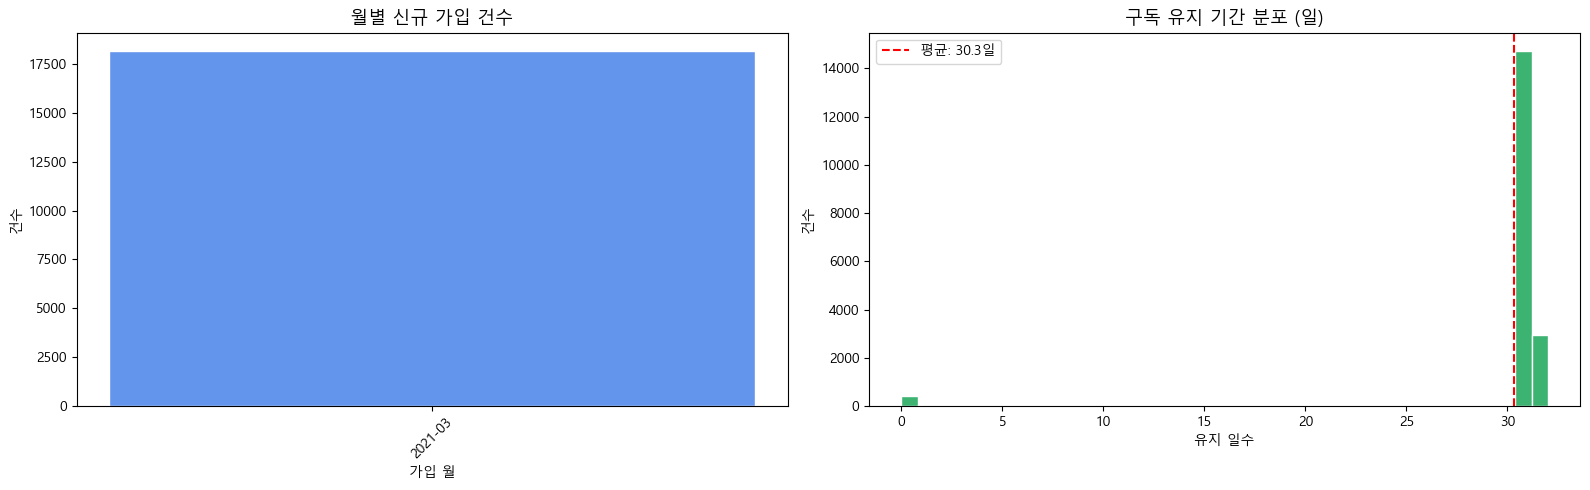


구독 유지 기간 평균: 30.3일
구독 유지 기간 최솟값: 0일
구독 유지 기간 최댓값: 32일


In [8]:
# 날짜 컬럼을 datetime 형식으로 변환합니다 (문자열 → 날짜 타입)
df['reg_date'] = pd.to_datetime(df['reg_date'])
df['end_date'] = pd.to_datetime(df['end_date'])

# 구독 유지 기간(일수) 계산: 종료일 - 등록일
df['subscription_days'] = (df['end_date'] - df['reg_date']).dt.days

# 가입 월(YYYY-MM) 컬럼 추가
df['reg_month'] = df['reg_date'].dt.to_period('M').astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# [왼쪽] 월별 신규 가입 건수 추이
monthly = df['reg_month'].value_counts().sort_index()
axes[0].bar(monthly.index, monthly.values, color='cornflowerblue', edgecolor='white')
axes[0].set_title('월별 신규 가입 건수', fontsize=13)
axes[0].set_xlabel('가입 월')
axes[0].set_ylabel('건수')
axes[0].tick_params(axis='x', rotation=45)

# [오른쪽] 구독 유지 기간 분포 히스토그램
axes[1].hist(df['subscription_days'].dropna(), bins=40, color='mediumseagreen', edgecolor='white')
axes[1].set_title('구독 유지 기간 분포 (일)', fontsize=13)
axes[1].set_xlabel('유지 일수')
axes[1].set_ylabel('건수')
# 평균값 수직선 표시
mean_days = df['subscription_days'].mean()
axes[1].axvline(mean_days, color='red', linestyle='--', label=f'평균: {mean_days:.1f}일')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n구독 유지 기간 평균: {mean_days:.1f}일")
print(f"구독 유지 기간 최솟값: {df['subscription_days'].min():.0f}일")
print(f"구독 유지 기간 최댓값: {df['subscription_days'].max():.0f}일")

## 7단계. 이탈 방지(Churn Prevention) 분석

> `is_churn_prevented` 컬럼을 기준으로 이탈 방지 여부에 따라 다른 변수들이 어떻게 다른지 비교합니다.

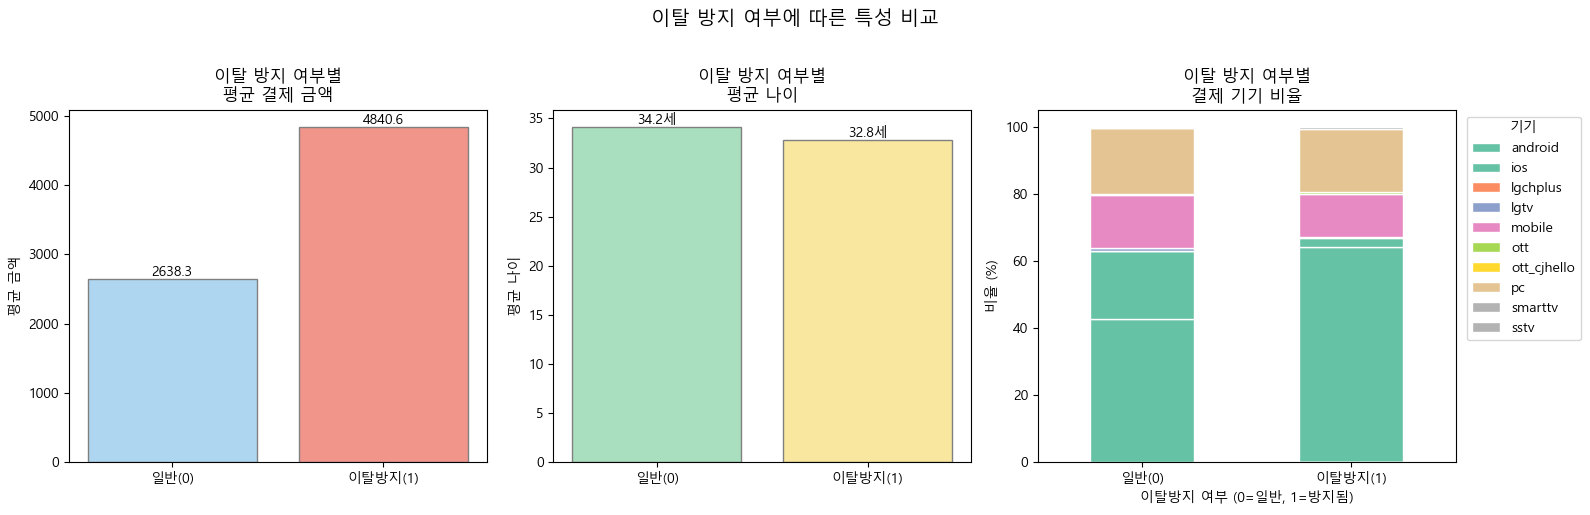

In [9]:
# 이탈 방지 여부를 이진(0/1)으로 변환해 분석하기 쉽게 만듭니다
# 'O'이면 이탈 방지됨(1), 그 외는 아님(0)
df['churn_flag'] = (df['is_churn_prevented'] == 'O').astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# [1] 이탈 방지 여부별 평균 결제 금액 비교
# 이탈 방지된 사용자가 더 많이 결제했는지 확인
amount_by_churn = df.groupby('churn_flag')['amount'].mean()
axes[0].bar(['일반(0)', '이탈방지(1)'], amount_by_churn.values,
            color=['#AED6F1', '#F1948A'], edgecolor='gray')
axes[0].set_title('이탈 방지 여부별\n평균 결제 금액', fontsize=12)
axes[0].set_ylabel('평균 금액')
for i, v in enumerate(amount_by_churn.values):
    axes[0].text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=10)

# [2] 이탈 방지 여부별 평균 나이 비교
age_by_churn = df.groupby('churn_flag')['age'].mean()
axes[1].bar(['일반(0)', '이탈방지(1)'], age_by_churn.values,
            color=['#A9DFBF', '#F9E79F'], edgecolor='gray')
axes[1].set_title('이탈 방지 여부별\n평균 나이', fontsize=12)
axes[1].set_ylabel('평균 나이')
for i, v in enumerate(age_by_churn.values):
    axes[1].text(i, v, f'{v:.1f}세', ha='center', va='bottom', fontsize=10)

# [3] 이탈 방지 여부별 결제 기기 비율 비교 (stacked bar)
device_churn = df.groupby(['churn_flag', 'payment_device']).size().unstack(fill_value=0)
device_churn_pct = device_churn.div(device_churn.sum(axis=1), axis=0) * 100
device_churn_pct.plot(kind='bar', stacked=True, ax=axes[2],
                      colormap='Set2', edgecolor='white')
axes[2].set_title('이탈 방지 여부별\n결제 기기 비율', fontsize=12)
axes[2].set_xlabel('이탈방지 여부 (0=일반, 1=방지됨)')
axes[2].set_ylabel('비율 (%)')
axes[2].set_xticklabels(['일반(0)', '이탈방지(1)'], rotation=0)
axes[2].legend(title='기기', bbox_to_anchor=(1.01, 1))

plt.suptitle('이탈 방지 여부에 따른 특성 비교', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8단계. 상관관계 분석

> 수치형 변수들 사이의 관계를 히트맵으로 표현합니다.  
> 상관계수가 1에 가까울수록 양의 관계, -1에 가까울수록 음의 관계, 0에 가까울수록 관계 없음을 의미합니다.

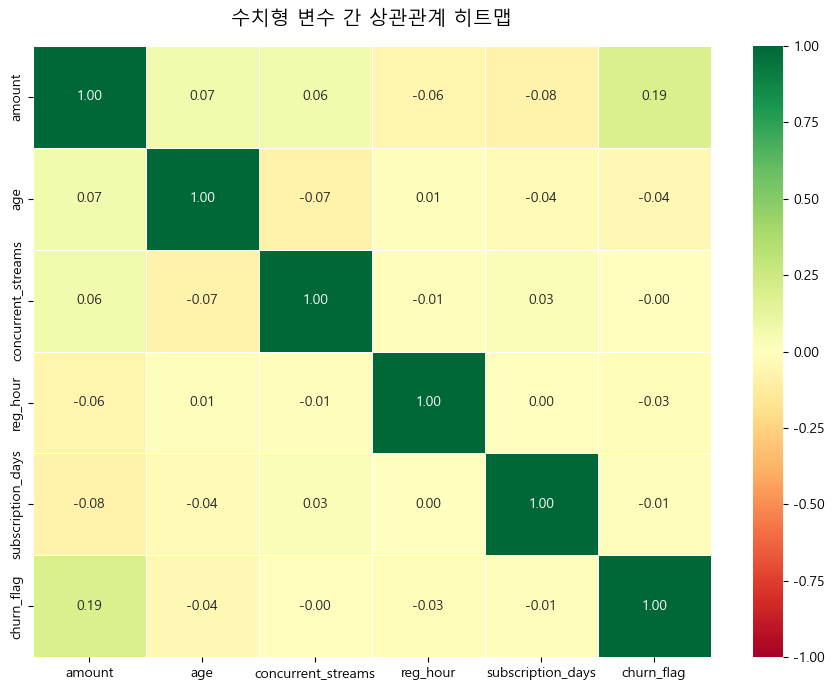

In [10]:
# 상관관계 분석에 사용할 수치형 컬럼 선택
corr_cols = ['amount', 'age', 'concurrent_streams', 'reg_hour', 'subscription_days', 'churn_flag']

# 상관계수 행렬 계산 (각 변수 쌍의 상관관계를 -1~1 사이 값으로 표현)
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))

# 히트맵 그리기: annot=True는 각 칸에 수치를 표시, fmt는 소수점 자릿수
sns.heatmap(corr_matrix,
            annot=True, fmt='.2f',
            cmap='RdYlGn',          # 빨강(-1) ~ 녹색(+1)
            center=0,               # 0을 중심(흰색)으로
            vmin=-1, vmax=1,
            linewidths=0.5,
            ax=ax)

ax.set_title('수치형 변수 간 상관관계 히트맵', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## 9단계. 상품별 분석

> 어떤 상품이 가장 많이 팔렸는지, 상품별 평균 금액과 이탈 방지율은 어떻게 다른지 확인합니다.

=== 상품별 요약 ===
product_cd  가입건수         평균금액  이탈방지율(%)
   pk_1487  6693  3143.209323      20.2
   pk_1488  2546  5715.593087      22.0
   pk_2025  2237  2801.788109      24.6
   pk_1489  2191  3459.356458      18.3
   pk_1508  2130     9.990000       2.4
   pk_2026   632  4773.496835      25.5
   pk_1506   614    13.490000       4.6
   pk_2027   547  2256.032907      18.3
   pk_1507   208    16.490000       1.9
   pk_2005   115  3858.695652      21.7
    pk_844    51    10.990000       0.0
   pk_2029    33  2198.484848      21.2
   pk_1136    32    10.990000       0.0
    pk_121    27  6797.777778      18.5
   pk_1494    24 13750.000000      20.8
    pk_845     9    14.290000       0.0
    pk_123     7 10900.000000       0.0
   pk_1139     7    14.290000       0.0
   pk_1509     7    16.490000       0.0
    pk_118     6  5900.000000      16.7
   pk_2028     6 13750.000000      16.7
    pk_139     6     9.890000      16.7
    pk_141     5    10.990000       0.0
    pk_188     5  5900.00

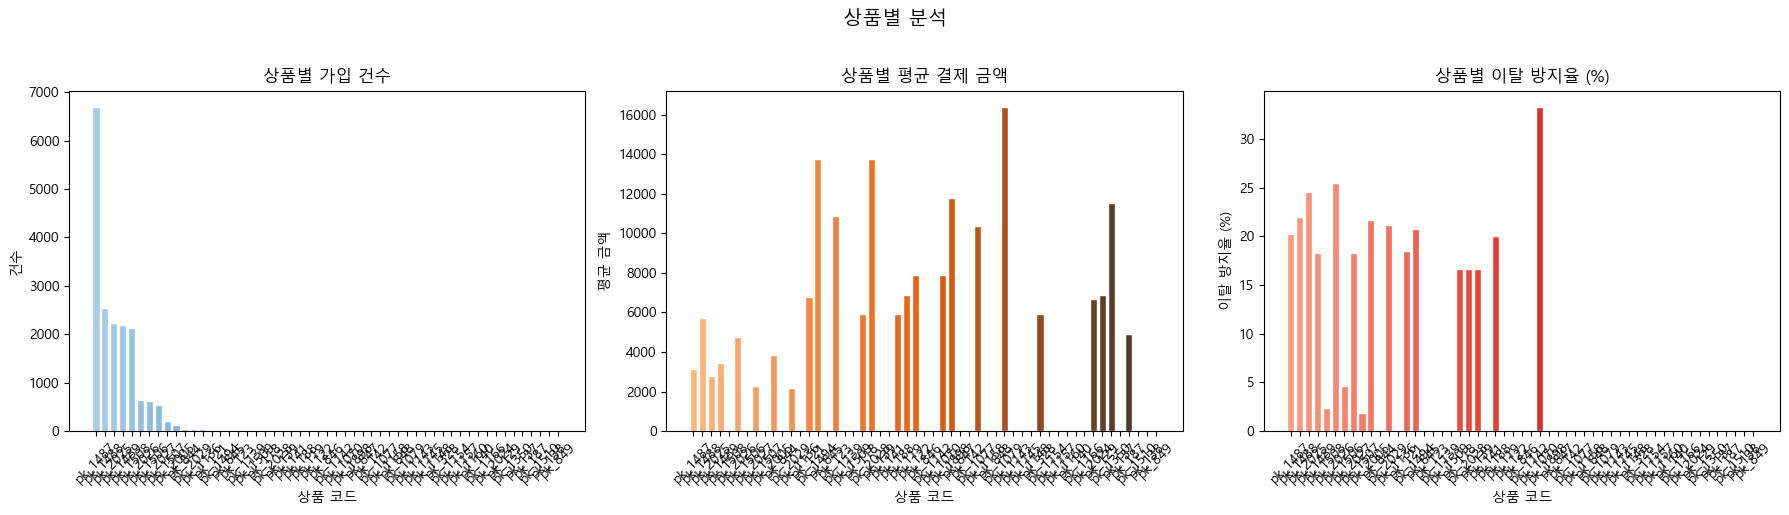

In [11]:
# 상품별 가입 건수, 평균 금액, 이탈 방지율 집계
product_summary = df.groupby('product_cd').agg(
    가입건수=('user_no', 'count'),
    평균금액=('amount', 'mean'),
    이탈방지율=('churn_flag', 'mean')   # 이탈 방지율: 이탈 방지된 비율 (0~1)
).reset_index()
product_summary['이탈방지율(%)'] = (product_summary['이탈방지율'] * 100).round(1)
product_summary = product_summary.sort_values('가입건수', ascending=False)

print("=== 상품별 요약 ===")
print(product_summary[['product_cd', '가입건수', '평균금액', '이탈방지율(%)']].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# [1] 상품별 가입 건수
axes[0].bar(product_summary['product_cd'], product_summary['가입건수'],
            color=sns.color_palette('Blues_d', len(product_summary)), edgecolor='white')
axes[0].set_title('상품별 가입 건수', fontsize=12)
axes[0].set_xlabel('상품 코드')
axes[0].set_ylabel('건수')
axes[0].tick_params(axis='x', rotation=45)

# [2] 상품별 평균 결제 금액
axes[1].bar(product_summary['product_cd'], product_summary['평균금액'],
            color=sns.color_palette('Oranges_d', len(product_summary)), edgecolor='white')
axes[1].set_title('상품별 평균 결제 금액', fontsize=12)
axes[1].set_xlabel('상품 코드')
axes[1].set_ylabel('평균 금액')
axes[1].tick_params(axis='x', rotation=45)

# [3] 상품별 이탈 방지율
axes[2].bar(product_summary['product_cd'], product_summary['이탈방지율(%)'],
            color=sns.color_palette('Reds_d', len(product_summary)), edgecolor='white')
axes[2].set_title('상품별 이탈 방지율 (%)', fontsize=12)
axes[2].set_xlabel('상품 코드')
axes[2].set_ylabel('이탈 방지율 (%)')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('상품별 분석', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10단계. 주요 인사이트 정리

EDA를 통해 확인할 수 있는 주요 관찰 포인트:

1. **결측치**: `is_churn_prevented`, `repurchase`, `is_user_verified`, `promotion_yn` 등 일부 컬럼에 결측치가 많음 → 빈 값 = "해당 없음"을 의미할 가능성이 높음
2. **상품 구성**: 여러 상품 코드가 존재하며, 특정 상품에 가입이 집중되어 있는지 확인 가능
3. **결제 기기**: PC / Android / iOS 중 어느 기기가 주 채널인지 파악 가능
4. **이탈 방지**: 전체 대비 이탈 방지 처리된 비율, 이탈 방지된 사용자의 금액·나이·기기 특성이 다른지 비교
5. **구독 기간**: 대부분 약 30일(월정액) 또는 특정 기간에 집중되어 있는지 확인
6. **등록 시각**: 특정 시간대에 가입이 몰리는지 확인 가능 (마케팅 타이밍 참고)